# Analítica Avanzada de Datos
-------------------------------------

## Práctica 2. Predicción de Gastos Médicos
#### Nombres: ...
**Objetivo:** Predecir el costo del seguro médico (charges) basado en el Índice de Masa Corporal (bmi), filtrando valores atípicos y preparando el dataset.
El dataset que utilizarán es **"US Health Insurance Dataset"**  https://www.kaggle.com/datasets/teertha/ushealthinsurancedataset

### Parte 1.
#### Deben de realizar:
##### **1. Carga y exploración inicial**
##### **2. Limpieza del dataset**
    * Verificación de nulos
    * Outliers
    * Análisis exploratorio de datos (EDA)

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [11]:
data_raw = pd.read_csv('insurance.csv')
data_raw.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

data_raw = pd.read_csv('./insurance.csv')
data_raw

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [13]:
data_raw.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [14]:
data_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


Para poder realizar un analsis del dataset se busca identidicar el significado de las variables:
- age (edad)
    Representa la edad del cliente, es un dato de tipo entero.
- sex (sexo)
    Representa el sexo del cliente, es un dato de tipo cadena.
- bmi (imc/indice de masa coportal)
    Representa el indice de masa corporal del cliente, es un dato de tipo flotante.
- childen (hijos)
    Representa el numero de hijos del cliente, es un dato de tipo entero.
- smoker (fumador)
    Representa si el cliente es fumador o no, es un dato de tipo cadena(si o no).
- region
    Representa la parte especifica de residencia del cliente en Estados Unidos(norte, sur, este u oeste), es un dato de tipo cadena.
- charges (cargos)
    Representa los cargos medicos facturados del seguro del cliente, es un dato de tipo flotante.


Este dataset es utlizado con el proposito de carculo de costo para seguros, las variables presentan factores de interes para las aseguradoras al momento de determinvar la viabilidad y rentabilidad de un cliente segun las caracteristicas que posee.

# Limpieza del data set

In [15]:
# Verificar la existencia de valores nulos
data_raw.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [16]:
# Se hace una separacion de las dimensiones numericas y las categoricas
numericas = ['age', 'bmi', 'children', 'charges']
categoricas = ['sex', 'smoker', 'region']

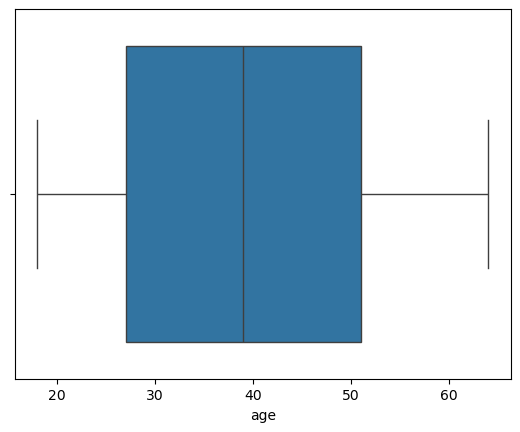

In [17]:
# Presencia de valores atipicos
sns.boxplot(x=data_raw['age'])
plt.show()

El boxplot de age muestra una distribución relativamente simétrica, con una mediana cercana a los 40 años situada al centro de la caja. Los bigotes abarcan aproximadamente desde los 18 hasta los 64 años y no se observan puntos fuera de ellos, lo cual indica ausencia de valores atípicos según la regla de 1.5·IQR. Esto sugiere que la variable edad está bien distribuida y no requiere tratamiento adicional por outliers.

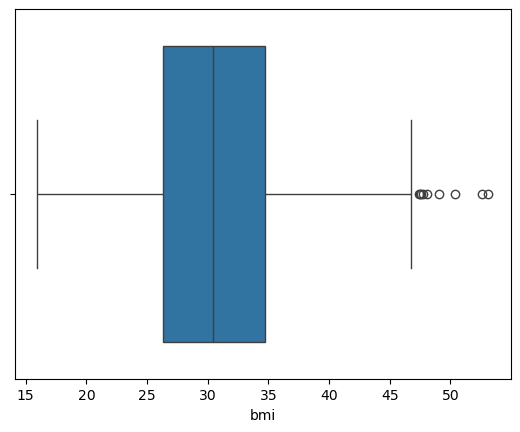

In [18]:
sns.boxplot(x=data_raw['bmi'])
plt.show()

El boxplot de bmi muestra una mediana cercana a 30 y un IQR ubicado aproximadamente entre 26 y 34. Aunque la mayor parte de los valores se concentra en ese rango, aparecen varios puntos por encima del bigote superior, correspondientes a valores atípicos altos (IMC elevado). Esto refleja una cola derecha en la distribución, indicando que existen personas con IMC significativamente mayor al promedio, lo cual debe considerarse para el análisis al aplicar técnicas como filtrado por IQR o revisión de su impacto en el modelo de regresión.

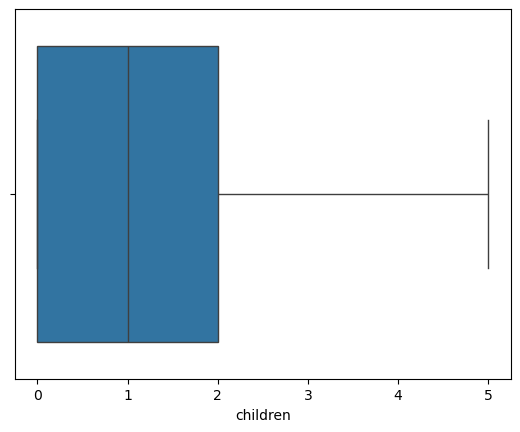

In [19]:
sns.boxplot(x=data_raw['children'])
plt.show()

En el boxplot de children se aprecia que la mayoría de los valores se concentran entre 0 y 2 hijos, con una mediana cercana a 1. Los bigotes se extienden hasta 5 hijos y no aparecen puntos fuera de estos límites, por lo que no se detectan outliers. La distribución es esperada para una variable discreta y no presenta valores extremos que necesiten corrección o filtrado.

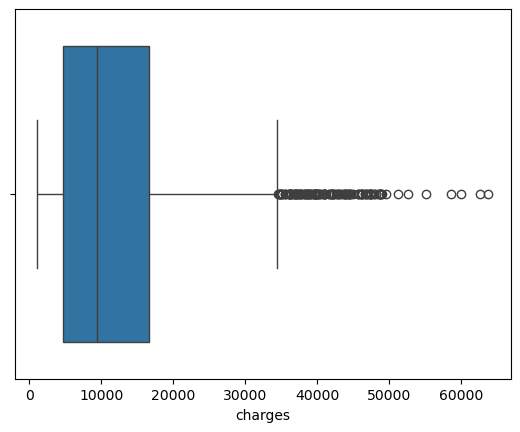

In [20]:
sns.boxplot(x=data_raw['charges'])
plt.show()

El boxplot de charges evidencia una distribución fuertemente asimétrica hacia la derecha, con una mediana alrededor de 10 000 y un IQR entre aproximadamente 7 000 y 16 000. A partir del bigote superior (~35 000) se observa una gran cantidad de puntos dispersos, lo cual indica la presencia de muchos outliers de alto costo. Estos valores extremos representan casos de gastos médicos muy elevados y pueden influir de manera considerable en la regresión lineal, por lo que es recomendable aplicar filtrado o considerar transformaciones como el logaritmo.

## Observar las distribuciones de las clases

In [21]:
numericas.hist(bins=20, figsize=(15, 10), color='teal', edgecolor='black')
plt.tight_layout()
plt.show()

AttributeError: 'list' object has no attribute 'hist'


##### **3. Visualización**
##### **4. Modelado (Regresión Lineal)**
##### **5. Evaluación del modelo ($R^2$,MSE,Coeficientes)**

# Visualización

Después de realizar la limpieza del dataset y antes de entrar de lleno con el modelo, es necesario visualizar los datos, es por ello que a continuación se presenta los siguientes gráficos de dispersión en 3d rotados de las variables age, bmi y la objetivo charges.

In [ ]:
data_clean.loc[:, ['age', 'bmi', 'charges']]

xs = data_clean['age']
ys = data_clean['bmi']
zs = data_clean ['charges']


fig = plt.figure(figsize=(18,10))

angulos = [
    (20, 30),
    (30, 120),
    (45, 210),
    (60, 300),
    (90, 0),
    (10, 180)
]

for i, (elev, azim) in enumerate(angulos):
    ax = fig.add_subplot(2, 3, i+1, projection='3d')
    ax.scatter(xs, ys, zs)
    ax.view_init(elev=elev, azim=azim)
    ax.set_title(f"Elevación={elev}, Rotación={azim}")

plt.tight_layout()
plt.show()

Se puede observar que mientras más grande es la edad y el bmi el costo del seguro médico crece. Sin embargo de momento no podemos aplicar el modelo, falta analizar otra variable númerica, la cual es el número de hijos, es por ello que se presenta el siguiente gráfico de dispersión en 2d incluyendo las varibales age, bmi, children y charges

In [ ]:
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

x = data_clean['age']
y = data_clean['bmi']
z = data_clean['children']
c = data_clean['charges']

scatter = ax.scatter(
    x, y, z, 
    c=c, 
    cmap='magma', 
    s=40,          # Tamaño de los puntos
    alpha=0.8,     # Transparencia
    edgecolors='w',# Borde blanco
    linewidth=0.5
)
cbar = fig.colorbar(scatter, ax=ax, shrink=0.5, aspect=15, pad=0.1)
cbar.set_label('Costo del Seguro (Charges) - USD', fontsize=12, labelpad=10)
ax.set_xlabel('Edad (Años)', fontsize=11, labelpad=10)
ax.set_ylabel('Índice de Masa Corporal (BMI)', fontsize=11, labelpad=10)
ax.set_zlabel('Número de Hijos', fontsize=11, labelpad=10)
plt.title('Impacto de Edad, BMI e Hijos sobre los Cargos (Variable Objetivo)', fontsize=14, pad=20)
ax.view_init(elev=20, azim=45) 
# Mostrar la gráfica
plt.show()

Como se puede observar, no se ve simpleme vista la tendencia de los datos en más dimensiones. De forma algo apresurada se puede ver que el costo del seguro es más bajo conforme age, bmi y children bajas. Pero para ver de manera númerica como es que estos datos se relacionan podemos hacer una matriz de correlación de pearson.

In [ ]:
corr1 = data_clean.loc[:, ['age', 'children', 'bmi', 'charges']].corr()


fig = plt.figure(figsize=(12, 9))

# Pearson
sns.heatmap(corr1,cmap='viridis', annot = True)


plt.tight_layout()
plt.show()

Se puede observar que la relación lineal entre nuestra variable objetivo y las númericas no es del todo alta.

# Modelado

In [ ]:
X = data_clean.loc[:, ['age', 'bmi', 'children']]
y = data_clean['charges']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Modelado
model = LinearRegression()

model.fit(X_train, y_train)


# Evaluación

In [ ]:

y_pred = model.predict(X_test)

# Evaluación
print("Coeficientes:", model.coef_)
print("Intercepto:", model.intercept_)
print("R2:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

### Parte 2.
Para esta sección deben:
1. Convierte la variable *smoker* en numérica con *ONE-HOT ENCODING*
2. Ahora usen dos variables predictoras (Regresión Lineal Múltiple) para ver cómo mejora la precisión.
3. Vuelvan a modelar y calcular las métricas de desempeño
4. Comparen los resultados, ¿Qué observan?

### Parte 3.
1. ¿Qué pasaría si incluimos también la edad (age)? Programen lo necesario para poder contestar la pregunta

<span style="color:blue">**Una vez concluida su práctica contesten el siguiente cuestionario de manera individual.**</span>
https://forms.gle/n4zWVSt3Cr6szXmk8